In [2]:

# Step 1: Setup and verify all four model checkpoints

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset

from pathlib import Path
import numpy as np
import random
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Paths (relative to ml/notebooks)
project_dir = Path("..")
processed_dir = project_dir / "data" / "processed"
train_dir = processed_dir / "Training"
test_dir = processed_dir / "Testing"

checkpoint_dir = project_dir / "results" / "checkpoints"
metrics_dir = project_dir / "results" / "metrics"

checkpoint_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Four trained model checkpoints
checkpoint_paths = {
    "efficientnet_b0": checkpoint_dir / "efficientnet_b0_finetuned_best.pth",
    "resnet18": checkpoint_dir / "resnet18_best.pth",
    "densenet201": checkpoint_dir / "densenet201_best.pth",
    "mobilenet_v3_large": checkpoint_dir / "mobilenet_v3_large_best.pth"
}

print("Device:", device)
print("\nDataset paths:")
print("Training directory exists:", train_dir.exists())
print("Testing directory exists:", test_dir.exists())

print("\nCheckpoint verification:")
for model_name, path in checkpoint_paths.items():
    print(f"{model_name}: {'FOUND' if path.exists() else 'MISSING'}")
    print(" ", path)

missing = [
    name for name, path in checkpoint_paths.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        f"Missing checkpoints: {missing}"
    )

print("\nAll four checkpoints are available.")

Device: cpu

Dataset paths:
Training directory exists: True
Testing directory exists: True

Checkpoint verification:
efficientnet_b0: FOUND
  ..\results\checkpoints\efficientnet_b0_finetuned_best.pth
resnet18: FOUND
  ..\results\checkpoints\resnet18_best.pth
densenet201: FOUND
  ..\results\checkpoints\densenet201_best.pth
mobilenet_v3_large: FOUND
  ..\results\checkpoints\mobilenet_v3_large_best.pth

All four checkpoints are available.


In [3]:

# Step 2: Load trained models and prepare feature extractors

# Load checkpoint files
checkpoints = {
    name: torch.load(path, map_location=device, weights_only=False)
    for name, path in checkpoint_paths.items()
}

# 1. EfficientNet-B0
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(1280, 4)
efficientnet.load_state_dict(
    checkpoints["efficientnet_b0"]["model_state_dict"]
)
efficientnet.classifier = nn.Identity()

# 2. ResNet-18
resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(512, 4)
resnet18.load_state_dict(
    checkpoints["resnet18"]["model_state_dict"]
)
resnet18.fc = nn.Identity()

# 3. DenseNet-201
densenet201 = models.densenet201(weights=None)
densenet201.classifier = nn.Linear(1920, 4)
densenet201.load_state_dict(
    checkpoints["densenet201"]["model_state_dict"]
)
densenet201.classifier = nn.Identity()

# 4. MobileNetV3-Large
mobilenet = models.mobilenet_v3_large(weights=None)
mobilenet.classifier[3] = nn.Linear(1280, 4)
mobilenet.load_state_dict(
    checkpoints["mobilenet_v3_large"]["model_state_dict"]
)
mobilenet.classifier = nn.Identity()

# Store models in one dictionary
feature_extractors = {
    "efficientnet_b0": efficientnet,
    "resnet18": resnet18,
    "densenet201": densenet201,
    "mobilenet_v3_large": mobilenet
}

# Set all models to evaluation mode
for name, extractor in feature_extractors.items():
    extractor = extractor.to(device)
    extractor.eval()
    feature_extractors[name] = extractor

print("All four trained models loaded as feature extractors.")

All four trained models loaded as feature extractors.


In [4]:

# Step 3: Verify feature-vector dimensions

dummy_input = torch.randn(1, 3, 224, 224).to(device)

feature_dimensions = {}

with torch.no_grad():
    for name, extractor in feature_extractors.items():
        features = extractor(dummy_input)

        # Flatten if output has spatial dimensions
        features = torch.flatten(features, start_dim=1)

        feature_dimensions[name] = features.shape[1]

        print(
            f"{name}: feature shape = {features.shape}"
        )

total_features = sum(feature_dimensions.values())

print("\nTotal concatenated feature dimensions:", total_features)

efficientnet_b0: feature shape = torch.Size([1, 1280])
resnet18: feature shape = torch.Size([1, 512])
densenet201: feature shape = torch.Size([1, 1920])
mobilenet_v3_large: feature shape = torch.Size([1, 960])

Total concatenated feature dimensions: 4672


In [5]:
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# Dataset paths relative to the notebook's working directory
TRAIN_DIR = Path("../data/processed/Training")
TEST_DIR = Path("../data/processed/Testing")

# Check that paths exist
print("Training path:", TRAIN_DIR.resolve())
print("Training path exists:", TRAIN_DIR.exists())
print("Testing path exists:", TEST_DIR.exists())

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    str(TRAIN_DIR),
    transform=transform
)

print("Class mapping:", train_dataset.class_to_idx)

targets = np.array(train_dataset.targets)
indices = np.arange(len(train_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Classes:", train_dataset.classes)

Training path: D:\Projects\Medexplain_AI\ml\data\processed\Training
Training path exists: True
Testing path exists: True
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 4343
Validation images: 1086
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
import torch
from tqdm.auto import tqdm

def extract_features(loader, split_name):
    all_features = []
    all_labels = []

    for images, labels in tqdm(loader, desc=f"Extracting {split_name}"):
        images = images.to(device)

        with torch.no_grad():
            features = [
                feature_extractors["efficientnet_b0"](images),
                feature_extractors["resnet18"](images),
                feature_extractors["densenet201"](images),
                feature_extractors["mobilenet_v3_large"](images),
            ]

            # Concatenate feature vectors: 1280 + 512 + 1920 + 960 = 4672
            combined_features = torch.cat(features, dim=1)

        all_features.append(combined_features.cpu())
        all_labels.append(labels)

    return (
        torch.cat(all_features, dim=0),
        torch.cat(all_labels, dim=0)
    )


# Extract features
train_features, train_labels = extract_features(
    train_loader, "training"
)

val_features, val_labels = extract_features(
    val_loader, "validation"
)

print("Training feature shape:", train_features.shape)
print("Training labels shape:", train_labels.shape)
print("Validation feature shape:", val_features.shape)
print("Validation labels shape:", val_labels.shape)

Extracting training:   0%|          | 0/272 [00:00<?, ?it/s]

Extracting validation:   0%|          | 0/68 [00:00<?, ?it/s]

Training feature shape: torch.Size([4343, 4672])
Training labels shape: torch.Size([4343])
Validation feature shape: torch.Size([1086, 4672])
Validation labels shape: torch.Size([1086])


In [7]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Create datasets from cached features
fusion_train_dataset = TensorDataset(train_features, train_labels)
fusion_val_dataset = TensorDataset(val_features, val_labels)

fusion_train_loader = DataLoader(
    fusion_train_dataset,
    batch_size=64,
    shuffle=True
)

fusion_val_loader = DataLoader(
    fusion_val_dataset,
    batch_size=64,
    shuffle=False
)

# Fusion head: 4672 combined features -> 4 classes
class FusionHead(nn.Module):
    def __init__(self, input_dim=4672, num_classes=4):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


fusion_head = FusionHead().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    fusion_head.parameters(),
    lr=0.001
)

print(fusion_head)
print("Trainable fusion-head parameters:",
      sum(p.numel() for p in fusion_head.parameters() if p.requires_grad))

FusionHead(
  (classifier): Sequential(
    (0): Linear(in_features=4672, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=4, bias=True)
  )
)
Trainable fusion-head parameters: 2394628


In [8]:
# Step 7: Train the feature-level fusion head

import copy
from pathlib import Path
from tqdm.auto import tqdm

EPOCHS = 30
best_val_accuracy = 0.0
patience = 5
epochs_without_improvement = 0

fusion_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_model_state = None

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    fusion_head.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in fusion_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = fusion_head(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    fusion_head.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in fusion_val_loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = fusion_head(features)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * features.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    # Save history
    fusion_history["train_loss"].append(train_loss)
    fusion_history["train_accuracy"].append(train_accuracy)
    fusion_history["val_loss"].append(val_loss)
    fusion_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # Early stopping / best model
    # -------------------------
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = copy.deepcopy(fusion_head.state_dict())
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": best_model_state,
                "input_dim": 4672,
                "num_classes": 4,
                "best_val_accuracy": best_val_accuracy,
                "epoch": epoch + 1,
                "class_to_idx": train_dataset.class_to_idx
            },
            checkpoint_dir / "feature_fusion_head_best.pth"
        )

        print("  Saved new best fusion-head checkpoint.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Restore best weights
if best_model_state is not None:
    fusion_head.load_state_dict(best_model_state)

# Save training history
with open(metrics_dir / "feature_fusion_training_history.json", "w") as f:
    json.dump(fusion_history, f, indent=4)

print("\nFusion-head training complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print("Best checkpoint:", checkpoint_dir / "feature_fusion_head_best.pth")
print("Training history:", metrics_dir / "feature_fusion_training_history.json")

Epoch [1/30] Train Loss: 0.2502 | Train Acc: 0.9028 | Val Loss: 0.1203 | Val Acc: 0.9521
  Saved new best fusion-head checkpoint.
Epoch [2/30] Train Loss: 0.0559 | Train Acc: 0.9804 | Val Loss: 0.1319 | Val Acc: 0.9521
Epoch [3/30] Train Loss: 0.0346 | Train Acc: 0.9889 | Val Loss: 0.1071 | Val Acc: 0.9622
  Saved new best fusion-head checkpoint.
Epoch [4/30] Train Loss: 0.0274 | Train Acc: 0.9919 | Val Loss: 0.0977 | Val Acc: 0.9715
  Saved new best fusion-head checkpoint.
Epoch [5/30] Train Loss: 0.0124 | Train Acc: 0.9968 | Val Loss: 0.1283 | Val Acc: 0.9659
Epoch [6/30] Train Loss: 0.0097 | Train Acc: 0.9968 | Val Loss: 0.1319 | Val Acc: 0.9715
Epoch [7/30] Train Loss: 0.0170 | Train Acc: 0.9940 | Val Loss: 0.2450 | Val Acc: 0.9263
Epoch [8/30] Train Loss: 0.0218 | Train Acc: 0.9924 | Val Loss: 0.0998 | Val Acc: 0.9705
Epoch [9/30] Train Loss: 0.0090 | Train Acc: 0.9963 | Val Loss: 0.1295 | Val Acc: 0.9659
Early stopping triggered.

Fusion-head training complete.
Best validation ac

Test images: 1584
Test class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Evaluating fusion model:   0%|          | 0/99 [00:00<?, ?it/s]


Feature-Level Fusion Test Results
---------------------------------
Accuracy:  0.9400
Precision: 0.9441
Recall:    0.9400
F1-score:  0.9387

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9936    0.8005    0.8867       386
  meningioma     0.8825    0.9623    0.9207       398
     notumor     0.9238    1.0000    0.9604       400
   pituitary     0.9778    0.9925    0.9851       400

    accuracy                         0.9400      1584
   macro avg     0.9444    0.9388    0.9382      1584
weighted avg     0.9441    0.9400    0.9387      1584



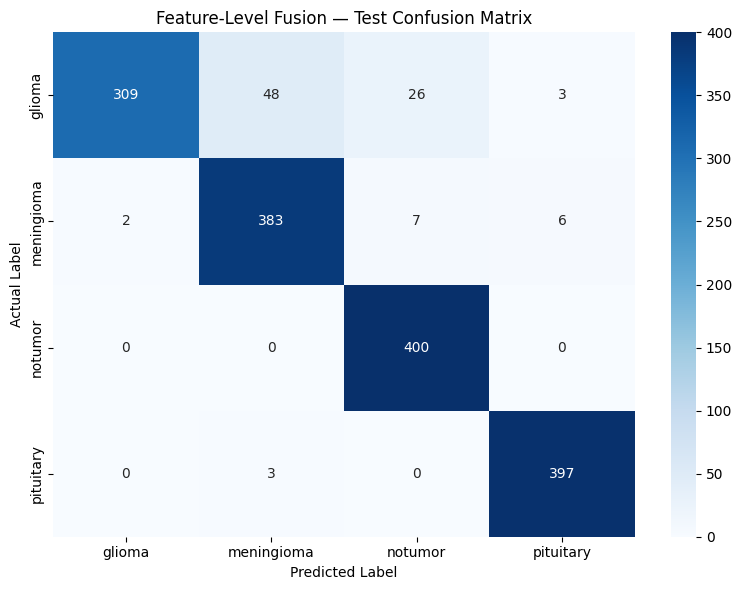


Saved test results: ..\results\metrics\feature_fusion_test_results.json
Saved confusion matrix: ..\results\metrics\feature_fusion_test_confusion_matrix.png


In [9]:
# Step 8: Evaluate feature-level fusion on the held-out test set

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch

# Load test dataset with the same preprocessing
test_dataset = datasets.ImageFolder(
    str(TEST_DIR),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Test images:", len(test_dataset))
print("Test class mapping:", test_dataset.class_to_idx)

# Load best fusion-head checkpoint
fusion_checkpoint_path = (
    checkpoint_dir / "feature_fusion_head_best.pth"
)

fusion_checkpoint = torch.load(
    fusion_checkpoint_path,
    map_location=device,
    weights_only=False
)

fusion_head.load_state_dict(
    fusion_checkpoint["model_state_dict"]
)
fusion_head.eval()

# Evaluate
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in tqdm(
        test_loader,
        desc="Evaluating fusion model"
    ):
        images = images.to(device)

        # Extract features from all four trained models
        features = [
            feature_extractors["efficientnet_b0"](images),
            feature_extractors["resnet18"](images),
            feature_extractors["densenet201"](images),
            feature_extractors["mobilenet_v3_large"](images)
        ]

        combined_features = torch.cat(features, dim=1)

        outputs = fusion_head(combined_features)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_true_labels.extend(
            labels.numpy()
        )

# Metrics
test_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("\nFeature-Level Fusion Test Results")
print("---------------------------------")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_true_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Feature-Level Fusion — Test Confusion Matrix")
plt.tight_layout()

# Save confusion matrix
confusion_path = (
    metrics_dir / "feature_fusion_test_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save numerical results
fusion_test_results = {
    "accuracy": float(test_accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        all_true_labels,
        all_predictions,
        target_names=test_dataset.classes,
        output_dict=True,
        zero_division=0
    )
}

results_path = (
    metrics_dir / "feature_fusion_test_results.json"
)

with open(results_path, "w") as f:
    json.dump(fusion_test_results, f, indent=4)

print("\nSaved test results:", results_path)
print("Saved confusion matrix:", confusion_path)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Model comparison based on final test evaluation
comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B0",
        "Test Accuracy": 92.17,
        "Weighted Precision": 92.60,
        "Weighted Recall": 92.17,
        "Weighted F1": 92.01
    },
    {
        "Model": "ResNet-18",
        "Test Accuracy": 81.88,
        "Weighted Precision": 82.30,
        "Weighted Recall": 81.88,
        "Weighted F1": 81.52
    },
    {
        "Model": "DenseNet-201",
        "Test Accuracy": 84.28,
        "Weighted Precision": 84.26,
        "Weighted Recall": 84.28,
        "Weighted F1": 83.73
    },
    {
        "Model": "MobileNetV3-Large",
        "Test Accuracy": 87.75,
        "Weighted Precision": 87.99,
        "Weighted Recall": 87.75,
        "Weighted F1": 87.47
    },
    {
        "Model": "Feature-Level Fusion",
        "Test Accuracy": 94.00,
        "Weighted Precision": 94.41,
        "Weighted Recall": 94.00,
        "Weighted F1": 93.87
    }
])

comparison

,Model,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,EfficientNet-B0,92.17,92.60,92.17,92.01
1,ResNet-18,81.88,82.30,81.88,81.52
2,DenseNet-201,84.28,84.26,84.28,83.73
3,MobileNetV3-Large,87.75,87.99,87.75,87.47
4,Feature-Level Fusion,94.00,94.41,94.00,93.87


In [12]:
from pathlib import Path

# Project paths
results_dir = Path("../results")
metrics_dir = results_dir / "metrics"
figures_dir = results_dir / "figures"
reports_dir = Path("../reports")

# Create directories if they don't exist
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Save comparison CSV
comparison_csv = metrics_dir / "model_comparison.csv"
comparison.to_csv(comparison_csv, index=False)

# Create Markdown table without requiring tabulate
markdown_table = (
    "| Model | Test Accuracy | Weighted Precision | Weighted Recall | Weighted F1 |\n"
    "|---|---:|---:|---:|---:|\n"
)

for _, row in comparison.iterrows():
    markdown_table += (
        f"| {row['Model']} | "
        f"{row['Test Accuracy']:.2f}% | "
        f"{row['Weighted Precision']:.2f}% | "
        f"{row['Weighted Recall']:.2f}% | "
        f"{row['Weighted F1']:.2f}% |\n"
    )

# Create Markdown report
report_content = f"""# Model Comparison — MedExplain AI

Test-set performance comparison of the four individual CNN backbones and the feature-level fusion model.

## Test Performance

{markdown_table}

## Dataset

- Task: Four-class brain MRI classification
- Classes: Glioma, Meningioma, No Tumor, Pituitary Tumor
- Test samples: 1,584

## Models

- EfficientNet-B0
- ResNet-18
- DenseNet-201
- MobileNetV3-Large
- Feature-Level Fusion
"""

comparison_report = reports_dir / "model_comparison.md"
comparison_report.write_text(report_content, encoding="utf-8")

print("Model comparison saved successfully.")
print()
print(f"CSV:    {comparison_csv.resolve()}")
print(f"Report: {comparison_report.resolve()}")

Model comparison saved successfully.

CSV:    D:\Projects\Medexplain_AI\ml\results\metrics\model_comparison.csv
Report: D:\Projects\Medexplain_AI\ml\reports\model_comparison.md


In [13]:
from pathlib import Path

checkpoint_dir = Path("../results/checkpoints")

checkpoint_files = {
    "EfficientNet-B0": checkpoint_dir / "efficientnet_b0_finetuned_best.pth",
    "ResNet-18": checkpoint_dir / "resnet18_best.pth",
    "DenseNet-201": checkpoint_dir / "densenet201_best.pth",
    "MobileNetV3-Large": checkpoint_dir / "mobilenet_v3_large_best.pth",
    "Fusion Head": checkpoint_dir / "feature_fusion_head_best.pth",
}

print("Checking model checkpoints...\n")

all_found = True

for model_name, path in checkpoint_files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"✓ {model_name:<22} {size_mb:.2f} MB")
    else:
        print(f"✗ {model_name:<22} NOT FOUND")
        all_found = False

print()

if all_found:
    print("All required checkpoints are available.")
else:
    print("One or more checkpoints are missing. Do not continue until they are available.")

Checking model checkpoints...

✓ EfficientNet-B0        15.60 MB
✓ ResNet-18              42.72 MB
✓ DenseNet-201           70.35 MB
✓ MobileNetV3-Large      16.25 MB
✓ Fusion Head            9.14 MB

All required checkpoints are available.


In [14]:
import torch
from pathlib import Path

# ---------------------------------------------------------
# Complete MedExplain AI Fusion Model Package
# ---------------------------------------------------------

checkpoint_dir = Path("../results/checkpoints")
fusion_dir = checkpoint_dir / "feature_fusion"
fusion_dir.mkdir(parents=True, exist_ok=True)

# Load the individual trained checkpoints
efficientnet_checkpoint = torch.load(
    checkpoint_dir / "efficientnet_b0_finetuned_best.pth",
    map_location="cpu"
)

resnet18_checkpoint = torch.load(
    checkpoint_dir / "resnet18_best.pth",
    map_location="cpu"
)

densenet201_checkpoint = torch.load(
    checkpoint_dir / "densenet201_best.pth",
    map_location="cpu"
)

mobilenet_checkpoint = torch.load(
    checkpoint_dir / "mobilenet_v3_large_best.pth",
    map_location="cpu"
)

fusion_head_checkpoint = torch.load(
    checkpoint_dir / "feature_fusion_head_best.pth",
    map_location="cpu"
)

# ---------------------------------------------------------
# Extract state dictionaries
# ---------------------------------------------------------

def get_state_dict(checkpoint):
    """
    Handles checkpoints saved either directly as a state_dict
    or inside common checkpoint dictionary keys.
    """
    if isinstance(checkpoint, dict):
        for key in ["model_state_dict", "state_dict", "model"]:
            if key in checkpoint:
                return checkpoint[key]

    return checkpoint


efficientnet_state = get_state_dict(efficientnet_checkpoint)
resnet18_state = get_state_dict(resnet18_checkpoint)
densenet201_state = get_state_dict(densenet201_checkpoint)
mobilenet_state = get_state_dict(mobilenet_checkpoint)
fusion_head_state = get_state_dict(fusion_head_checkpoint)

# ---------------------------------------------------------
# Create the complete package
# ---------------------------------------------------------

complete_fusion_package = {
    "model_name": "MedExplain AI Feature-Level Fusion Model",
    "architecture": {
        "backbones": [
            "EfficientNet-B0",
            "ResNet-18",
            "DenseNet-201",
            "MobileNetV3-Large"
        ],
        "fusion_type": "Feature-Level Fusion",
        "fusion_input_dimension": 4672,
        "fusion_hidden_dimension": 512,
        "num_classes": 4
    },

    "class_mapping": {
        "glioma": 0,
        "meningioma": 1,
        "notumor": 2,
        "pituitary": 3
    },

    "feature_dimensions": {
        "EfficientNet-B0": 1280,
        "ResNet-18": 512,
        "DenseNet-201": 1920,
        "MobileNetV3-Large": 960,
        "total": 4672
    },

    "backbone_state_dicts": {
        "efficientnet_b0": efficientnet_state,
        "resnet18": resnet18_state,
        "densenet201": densenet201_state,
        "mobilenet_v3_large": mobilenet_state
    },

    "fusion_head_state_dict": fusion_head_state,

    "preprocessing": {
        "image_size": [224, 224],
        "normalization_mean": [0.485, 0.456, 0.406],
        "normalization_std": [0.229, 0.224, 0.225],
        "input_channels": 3
    }
}

# ---------------------------------------------------------
# Save complete package
# ---------------------------------------------------------

output_path = fusion_dir / "medexplain_fusion_model.pth"

torch.save(
    complete_fusion_package,
    output_path
)

# ---------------------------------------------------------
# Verify saved artifact
# ---------------------------------------------------------

file_size_mb = output_path.stat().st_size / (1024 * 1024)

print("Complete fusion model package created successfully.")
print()
print(f"File: {output_path.resolve()}")
print(f"Size: {file_size_mb:.2f} MB")
print()
print("Included:")
print("✓ EfficientNet-B0")
print("✓ ResNet-18")
print("✓ DenseNet-201")
print("✓ MobileNetV3-Large")
print("✓ Fusion head")
print("✓ Class mapping")
print("✓ Feature dimensions")
print("✓ Preprocessing configuration")

Complete fusion model package created successfully.

File: D:\Projects\Medexplain_AI\ml\results\checkpoints\feature_fusion\medexplain_fusion_model.pth
Size: 154.05 MB

Included:
✓ EfficientNet-B0
✓ ResNet-18
✓ DenseNet-201
✓ MobileNetV3-Large
✓ Fusion head
✓ Class mapping
✓ Feature dimensions
✓ Preprocessing configuration
